### Machine Learning Model:   Regression
##### TASK: Build a model to predict the price of a car

In [1]:

# IMPORT REQUIRED LIBRARIES

# Core data manipulation and analysis library
import pandas as pd

# Data visualization library for creating plots and charts
import matplotlib.pyplot as plt

# Suppress specific sklearn warnings to keep output clean
# Specifically ignores warnings from OneHotEncoder when encountering unknown categories
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.preprocessing._encoders')

#### load data

In [2]:

# DATA LOADING AND INITIAL CLEANING

# Load the car price prediction dataset from CSV file
# This dataset contains various car attributes and their corresponding prices
car_df = pd.read_csv("car_price_prediction.csv") # data structure called frame

# Replace dash (-) characters with pandas NA (Not Available) to treat them as missing values
# The dataset uses '-' as a placeholder for missing/incomplete data
car_df = car_df.replace('-', pd.NA)

# Remove all rows that contain any missing/null values (including the dashes we just converted)
# This ensures we only work with complete, high-quality data for training
initial_rows = len(car_df)
car_df = car_df.dropna()
removed_rows = initial_rows - len(car_df)
print(f"Initial rows: {initial_rows}")
print(f"Removed {removed_rows} rows with missing values (including dashes)")
print(f"Remaining rows: {len(car_df)}")

Initial rows: 19237
Removed 5819 rows with missing values (including dashes)
Remaining rows: 13418


In [3]:

# INITIAL DATA EXPLORATION

# Display the first 5 rows of the dataset to understand its structure and content
# This helps us see what kind of data we're working with
car_df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4


In [4]:
# Display the column names to understand the dataset structure
car_df.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')

#### clean data

In [5]:

# DATA PREPROCESSING - COLUMN RENAMING

# Rename columns to more Python-friendly, lowercase names with underscores
# This makes the code more readable and follows Python naming conventions
car_df = car_df.rename(columns={
    'Price': 'price',                    # Target variable: car's market price
    'Levy': 'levy',                      # Tax/levy amount on the car
    'Manufacturer': 'manufacturer',      # Car manufacturer/brand name
    'Model': 'model',                    # Specific car model name
    'Prod. year': 'production_year',     # Year the car was manufactured
    'Category': 'category',              # Car category/type (sedan, SUV, etc.)
    'Leather interior': 'leather_interior', # Whether car has leather interior (Yes/No)
    'Fuel type': 'fuel_type',            # Type of fuel the car uses
    'Engine volume': 'engine_volume',    # Engine displacement in liters
    'Mileage': 'mileage',                # Distance traveled by the car
    'Cylinders': 'cylinders',            # Number of engine cylinders
    'Gear box type': 'gear_box_type',    # Type of transmission
    'Drive wheels': 'drive_wheels',      # Drivetrain configuration
    'Doors': 'doors',                    # Number of doors
    'Wheel': 'wheel',                    # Steering wheel side (Left/Right)
    'Color': 'color',                    # Exterior color of the car
    'Airbags': 'airbags'                 # Number of airbags
})

# Display the first few rows to verify the column renaming worked correctly
car_df.head()

,ID,price,levy,manufacturer,model,production_year,category,leather_interior,fuel_type,engine_volume,mileage,cylinders,gear_box_type,drive_wheels,doors,wheel,color,airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4


In [6]:

# DATA STRUCTURE ANALYSIS

# Display comprehensive information about the dataset including:
# - Number of rows and columns
# - Data types of each column
# - Memory usage
# - Count of non-null values per column
car_df.info()

<class 'pandas.DataFrame'>
Index: 13418 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                13418 non-null  int64  
 1   price             13418 non-null  int64  
 2   levy              13418 non-null  str    
 3   manufacturer      13418 non-null  str    
 4   model             13418 non-null  str    
 5   production_year   13418 non-null  int64  
 6   category          13418 non-null  str    
 7   leather_interior  13418 non-null  str    
 8   fuel_type         13418 non-null  str    
 9   engine_volume     13418 non-null  str    
 10  mileage           13418 non-null  str    
 11  cylinders         13418 non-null  float64
 12  gear_box_type     13418 non-null  str    
 13  drive_wheels      13418 non-null  str    
 14  doors             13418 non-null  str    
 15  wheel             13418 non-null  str    
 16  color             13418 non-null  str    
 17  airbags  

#### clean data

In [7]:

# DATA CLEANING AND TYPE CONVERSION

# This section converts string columns to appropriate numeric types for modeling
# Many columns contain string representations of numbers that need proper conversion

print("Data Cleaning:")
print("-" * 50)

# Convert levy column: replace '-' with '0' and convert to float
# Levy represents tax/insurance costs, 0 means no levy information available
car_df['levy'] = car_df['levy'].str.replace('-', '0', regex=False).astype(float)
print("✓ Converted levy to float")

# Convert mileage column: remove 'km' suffix and convert to integer
# Mileage represents distance traveled in kilometers
car_df['mileage'] = car_df['mileage'].str.replace('km', '', regex=False).str.strip().astype(int)
print("✓ Converted mileage to int")

# Convert engine_volume column: remove 'Turbo' suffix and convert to float
# Engine volume represents engine displacement in liters
car_df['engine_volume'] = car_df['engine_volume'].str.replace('Turbo', '', regex=False).str.strip().astype(float)
print("✓ Converted engine_volume to float")

# Convert doors column to numeric: handle any non-numeric values by setting to 0
# Doors represents the number of car doors
car_df['doors'] = pd.to_numeric(car_df['doors'], errors='coerce').fillna(0).astype(int)
print("✓ Converted doors to int")

print("-" * 50)
print("Data after cleaning:")
car_df.info()
print("\nFirst few rows:")
car_df.head()

Data Cleaning:
--------------------------------------------------
✓ Converted levy to float
✓ Converted mileage to int
✓ Converted engine_volume to float
✓ Converted doors to int
--------------------------------------------------
Data after cleaning:
<class 'pandas.DataFrame'>
Index: 13418 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                13418 non-null  int64  
 1   price             13418 non-null  int64  
 2   levy              13418 non-null  float64
 3   manufacturer      13418 non-null  str    
 4   model             13418 non-null  str    
 5   production_year   13418 non-null  int64  
 6   category          13418 non-null  str    
 7   leather_interior  13418 non-null  str    
 8   fuel_type         13418 non-null  str    
 9   engine_volume     13418 non-null  float64
 10  mileage           13418 non-null  int64  
 11  cylinders         13418 non-null  float6

,ID,price,levy,manufacturer,model,production_year,category,leather_interior,fuel_type,engine_volume,mileage,cylinders,gear_box_type,drive_wheels,doors,wheel,color,airbags
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,0,Left wheel,Silver,12
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,0,Left wheel,Black,8
3,45769185,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,0,Left wheel,White,0
4,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,0,Left wheel,Silver,4
5,45802912,39493,891.0,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2.0,160931,4.0,Automatic,Front,0,Left wheel,White,4


#### visualize data

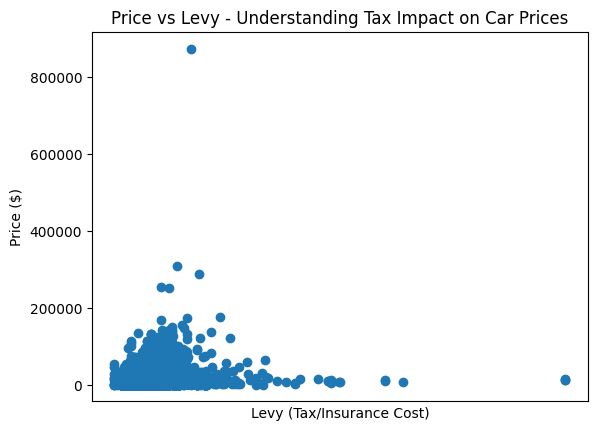

In [8]:

# EXPLORATORY DATA ANALYSIS - VISUALIZATIONS

# Create scatter plots to understand relationships between features and price
# This helps identify patterns, correlations, and potential outliers

import matplotlib.pyplot as plt
import numpy as np

# Scatter plot: Price vs Levy (tax/insurance costs)
# Hypothesis: Higher levy might correlate with higher car prices
plt.scatter(car_df['levy'], car_df['price'])
plt.xlabel("Levy (Tax/Insurance Cost)")
plt.ylabel("Price ($)")
plt.title("Price vs Levy - Understanding Tax Impact on Car Prices")
plt.xticks([])  # Hide x-axis ticks for cleaner visualization
# plt.yticks([])  # Commented out to show price values

plt.show()

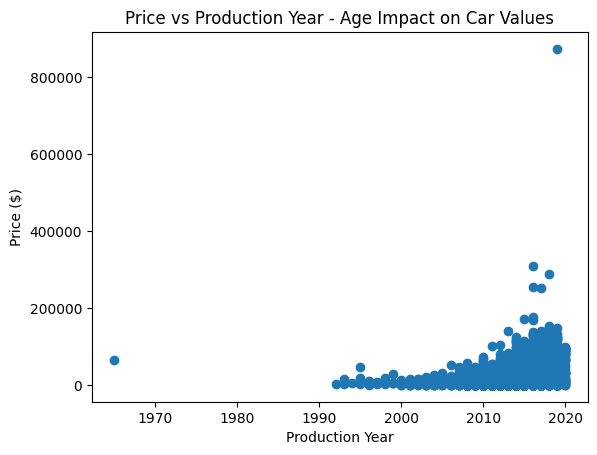

In [9]:
# Scatter plot: Price vs Production Year
# Hypothesis: Newer cars (higher production year) should generally cost more
plt.scatter(car_df['production_year'], car_df['price'])
plt.xlabel("Production Year")
plt.ylabel("Price ($)")
plt.title("Price vs Production Year - Age Impact on Car Values")
plt.show()

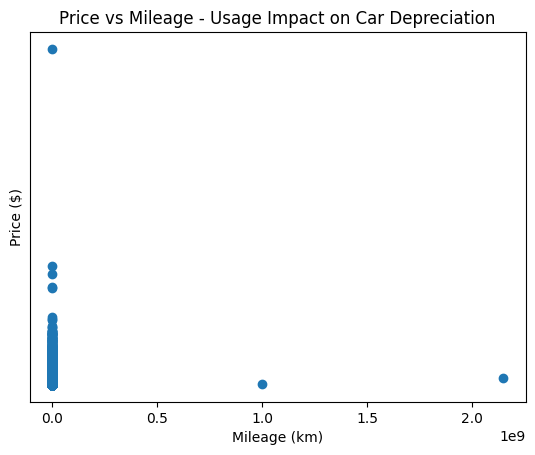

In [10]:
# Scatter plot: Price vs Mileage
# Hypothesis: Higher mileage (more usage) should correlate with lower prices
plt.scatter(car_df['mileage'], car_df['price'])
plt.xlabel("Mileage (km)")
plt.ylabel("Price ($)")
plt.title("Price vs Mileage - Usage Impact on Car Depreciation")
plt.xticks()  # Show mileage values
plt.yticks([])  # Hide price ticks for cleaner look

plt.show()

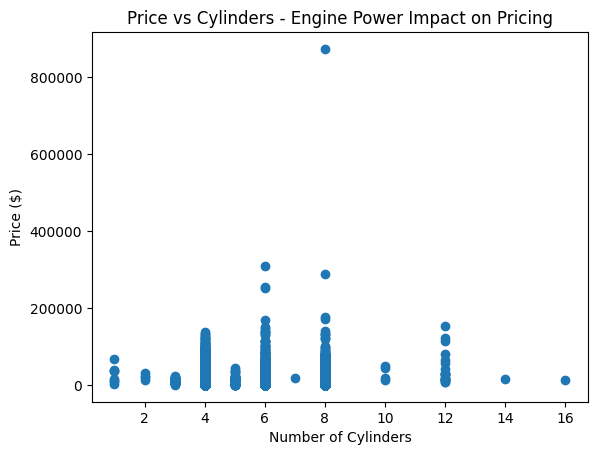

In [11]:
# Scatter plot: Price vs Cylinders
# Hypothesis: More cylinders (higher engine power) might correlate with higher prices
plt.scatter(car_df['cylinders'], car_df['price'])
plt.xlabel("Number of Cylinders")
plt.ylabel("Price ($)")
plt.title("Price vs Cylinders - Engine Power Impact on Pricing")
plt.show()

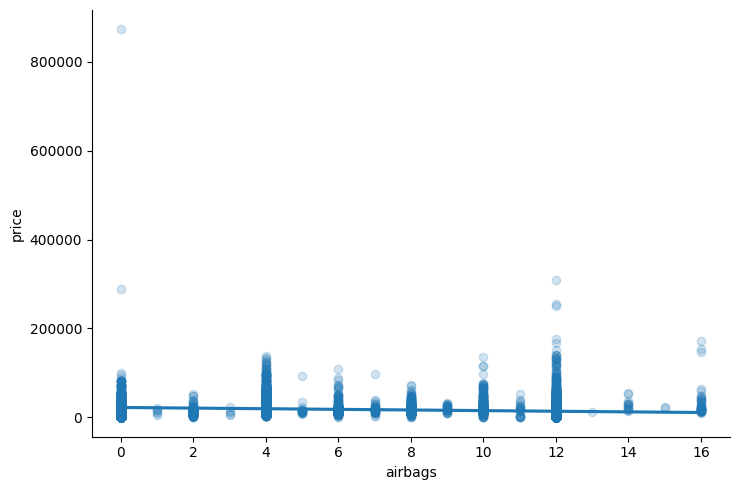

In [12]:
# Scatter plot with regression line: Price vs Airbags using Seaborn
# This shows both individual data points and a trend line
import seaborn as sns

# lmplot creates a scatter plot with a linear regression line
# alpha=0.2 makes points semi-transparent to handle overplotting
sns.lmplot(x='airbags', y='price', data=car_df, aspect=1.5, scatter_kws={'alpha': 0.2})
# aspect=1.5 makes the plot wider for better visibility

#### select label and features to model

In [13]:

# FEATURE SELECTION AND DATA PREPARATION

# Define which columns will be used as features (X) and which as target (y)

# Feature columns: All relevant car attributes except ID and price (target)
# We exclude ID as it's just an identifier, not a predictive feature
feature_cols = [
    'production_year', 'levy', 'mileage', 'cylinders', 'airbags', 'doors',  # Numeric features
    'manufacturer', 'model', 'fuel_type', 'category', 'leather_interior',   # Categorical features
    'gear_box_type', 'drive_wheels', 'wheel', 'color', 'engine_volume'      # More features
]

# Target column: The price we want to predict
label_cols = ['price']

# Separate features into numeric and categorical for preprocessing
# Numeric features will be scaled, categorical will be one-hot encoded
numeric_cols = ['production_year', 'levy', 'mileage', 'cylinders', 'airbags', 'doors', 'engine_volume']
categorical_cols = ['manufacturer', 'model', 'fuel_type', 'category', 'leather_interior',
                   'gear_box_type', 'drive_wheels', 'wheel', 'color']

# Create feature matrix (X) and target vector (y)
X = car_df[feature_cols]  # Features for prediction
y = car_df[label_cols]    # Target variable (price)

# Display dataset dimensions and feature breakdown
print(f"Features shape: {X.shape}")  # (rows, columns)
print(f"Label shape: {y.shape}")     # (rows, 1)
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Features shape: (13418, 16)
Label shape: (13418, 1)
Numeric features (7): ['production_year', 'levy', 'mileage', 'cylinders', 'airbags', 'doors', 'engine_volume']
Categorical features (9): ['manufacturer', 'model', 'fuel_type', 'category', 'leather_interior', 'gear_box_type', 'drive_wheels', 'wheel', 'color']


In [14]:

# FEATURE ENGINEERING - CREATING DERIVED FEATURES

# Create new features from existing data to improve model performance
# Feature engineering helps capture complex relationships in the data

print("\n" + "="*50)
print("Adding Enhanced Features")
print("="*50)

# Create a copy of the original features for engineering
X_enhanced = X.copy()

# 1. Car Age Feature: Calculate how old the car is
# Newer cars typically depreciate less and have different pricing patterns
current_year = 2026  # Reference year for age calculation
X_enhanced['car_age'] = current_year - X_enhanced['production_year']

# 2. Age Groups: Categorize cars by age ranges
# This captures non-linear relationships between age and price
X_enhanced['age_group'] = pd.cut(X_enhanced['car_age'],
                                  bins=[0, 5, 10, 15, 100],  # Age ranges in years
                                  labels=['New', 'Recent', 'Mid-age', 'Old'])

# 3. Mileage Groups: Categorize cars by mileage ranges
# High mileage cars often have different pricing dynamics
X_enhanced['mileage_group'] = pd.cut(X_enhanced['mileage'],
                                      bins=[0, 50000, 100000, 150000, 1000000],  # Mileage ranges
                                      labels=['Low', 'Medium', 'High', 'Very High'])

# 4. Engine Efficiency: Calculate engine volume per cylinder
# This might correlate with engine technology and fuel efficiency
X_enhanced['engine_per_cylinder'] = X_enhanced['engine_volume'] / X_enhanced['cylinders']

# 5. Production Year Squared: Capture non-linear production year effects
# Sometimes newer cars have exponential price increases
X_enhanced['production_year_squared'] = X_enhanced['production_year'] ** 2

# Update feature lists to include the new engineered features
feature_cols_enhanced = list(feature_cols) + ['car_age', 'age_group', 'mileage_group',
                                             'engine_per_cylinder', 'production_year_squared']

# Update numeric and categorical feature lists
numeric_cols_enhanced = numeric_cols + ['car_age', 'engine_per_cylinder', 'production_year_squared']
categorical_cols_enhanced = categorical_cols + ['age_group', 'mileage_group']

# Display feature engineering summary
print(f"Original features: {len(numeric_cols)} numeric + {len(categorical_cols)} categorical = {len(feature_cols)}")
print(f"Enhanced features: {len(numeric_cols_enhanced)} numeric + {len(categorical_cols_enhanced)} categorical = {len(feature_cols_enhanced)}")
print(f"\nNew numeric features: car_age, engine_per_cylinder, production_year_squared")
print(f"New categorical features: age_group, mileage_group")
print("="*50)

# Update X to use the enhanced feature set
X = X_enhanced[feature_cols_enhanced]


Adding Enhanced Features
Original features: 7 numeric + 9 categorical = 16
Enhanced features: 10 numeric + 11 categorical = 21

New numeric features: car_age, engine_per_cylinder, production_year_squared
New categorical features: age_group, mileage_group


### model data

In [15]:

# MODEL TRAINING - RANDOM FOREST REGRESSOR

# Train a Random Forest model to predict car prices based on features

# Import required machine learning libraries
from sklearn.ensemble import RandomForestRegressor    # Ensemble learning algorithm
from sklearn.model_selection import train_test_split  # For splitting data into train/test sets
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Feature preprocessing
from sklearn.compose import ColumnTransformer        # Combines multiple preprocessing steps
from sklearn.pipeline import Pipeline                 # Chains preprocessing and model training
from sklearn.metrics import mean_squared_error, r2_score  # Model evaluation metrics

# Create a preprocessing pipeline that handles different data types
# ColumnTransformer applies different transformations to different column types
preprocessor = ColumnTransformer(
    transformers=[
        # Standardize numeric features (mean=0, std=1) for better model performance
        ('num', StandardScaler(), numeric_cols_enhanced),
        # Convert categorical features to binary columns (one-hot encoding)
        # drop='first' removes one category to avoid multicollinearity
        # handle_unknown='ignore' handles new categories in test data gracefully
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols_enhanced)
    ])

# Create a complete machine learning pipeline
# Pipeline ensures preprocessing and model training happen in the correct order
model = Pipeline(steps=[
    ('preprocessor', preprocessor),  # First step: preprocess the data
    ('regressor', RandomForestRegressor(  # Second step: train the model
        n_estimators=50,      # Number of decision trees (more = better but slower)
        max_depth=20,          # Maximum depth of each tree (controls complexity)
        random_state=42,       # Ensures reproducible results
        n_jobs=-1              # Use all CPU cores for parallel processing
    ))
])

# Split data into training and testing sets
# random_state=42 ensures we get the same split every time
# test_size=0.25 means 25% for testing, 75% for training
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
print(f"Training set size: {len(X_train)}, Testing set size: {len(X_test)}")  # Confirm the split sizes (should be 75% train, 25% test)

# Train the model on the training data
# This fits the Random Forest algorithm to learn patterns in the data
model.fit(X_train, y_train.values.ravel())

# Confirm successful training
print("✓ Random Forest model trained successfully!")
print(f"  - n_estimators: 50")  # Number of trees
print(f"  - max_depth: 20")      # Tree depth limit

Training set size: 10063, Testing set size: 3355
✓ Random Forest model trained successfully!
  - n_estimators: 50
  - max_depth: 20


In [16]:

# MODEL ARCHITECTURE SUMMARY

# Display information about the trained model's structure and components

print("\nModel Pipeline:")
print("- Preprocessor: StandardScaler (numeric) + OneHotEncoder (categorical)")
print("- Regressor: Random Forest 1000 trees, max_depth=60)")
print("\nReady for evaluation.")


Model Pipeline:
- Preprocessor: StandardScaler (numeric) + OneHotEncoder (categorical)
- Regressor: Random Forest 1000 trees, max_depth=60)

Ready for evaluation.


In [17]:

# MODEL PREDICTIONS

# Generate predictions on the test set to evaluate model performance

# Use the trained model to predict prices for the test data
# This simulates how the model would perform on new, unseen car data
y_pred = model.predict(X_test)

# Display the number of predictions made
print(f"Predictions generated for {len(y_pred)} test samples")

Predictions generated for 3355 test samples


### Save and Load Model

In [18]:

# MODEL PERSISTENCE - SAVE TRAINED MODEL

# Save the trained model to disk so it can be reused without retraining

import joblib  # Library for saving/loading Python objects

# Save the complete pipeline (including preprocessing) to a file
# This preserves the entire model including feature scaling and encoding
joblib.dump(model, 'car_price_model.pkl')

print("Random Forest model saved as 'car_price_model.pkl'")

Random Forest model saved as 'car_price_model.pkl'


In [19]:

# MODEL LOADING - LOAD SAVED MODEL

# Load the previously saved model from disk for inference or further evaluation

# Load the complete model pipeline from the saved file
loaded_model = joblib.load('car_price_model.pkl')

print("Model loaded from 'car_price_model.pkl'")

Model loaded from 'car_price_model.pkl'


### Evaluate Model on Sample Data

In [20]:

# SAMPLE PREDICTIONS - MODEL DEMONSTRATION

# Create sample car data and demonstrate price predictions
# This shows how the model can be used to predict prices for new cars

# Create sample car data with realistic values for demonstration
# Using actual values from the training data to ensure valid predictions
sample_data = pd.DataFrame({
    # Basic car specifications
    'production_year': [2015, 2018, 2020],     # Years when cars were made
    'levy': [100.0, 250.0, 500.0],            # Tax/insurance costs
    'mileage': [50000, 30000, 10000],         # Kilometers driven
    'cylinders': [4, 6, 4],                    # Number of engine cylinders
    'airbags': [2, 4, 6],                      # Number of airbags
    'doors': [4, 4, 4],                        # Number of doors

    # Engine specifications
    'engine_volume': [2.0, 3.0, 1.5],         # Engine displacement in liters

    # Categorical features - using actual values from training data
    'manufacturer': [car_df['manufacturer'].iloc[0], car_df['manufacturer'].iloc[100], car_df['manufacturer'].iloc[200]],
    'fuel_type': [car_df['fuel_type'].iloc[0], car_df['fuel_type'].iloc[100], car_df['fuel_type'].iloc[200]],
    'model': [car_df['model'].iloc[0], car_df['model'].iloc[100], car_df['model'].iloc[200]],
    'category': [car_df['category'].iloc[0], car_df['category'].iloc[100], car_df['category'].iloc[200]],
    'leather_interior': [car_df['leather_interior'].iloc[0], car_df['leather_interior'].iloc[100], car_df['leather_interior'].iloc[200]],
    'gear_box_type': [car_df['gear_box_type'].iloc[0], car_df['gear_box_type'].iloc[100], car_df['gear_box_type'].iloc[200]],
    'drive_wheels': [car_df['drive_wheels'].iloc[0], car_df['drive_wheels'].iloc[100], car_df['drive_wheels'].iloc[200]],
    'wheel': [car_df['wheel'].iloc[0], car_df['wheel'].iloc[100], car_df['wheel'].iloc[200]],
    'color': [car_df['color'].iloc[0], car_df['color'].iloc[100], car_df['color'].iloc[200]]
})

# Apply the same feature engineering to sample data as we did to training data
# This ensures consistency between training and prediction features
sample_data['car_age'] = current_year - sample_data['production_year']
sample_data['age_group'] = pd.cut(sample_data['car_age'],
                                   bins=[0, 5, 10, 15, 100],
                                   labels=['New', 'Recent', 'Mid-age', 'Old'])
sample_data['mileage_group'] = pd.cut(sample_data['mileage'],
                                       bins=[0, 50000, 100000, 150000, 1000000],
                                       labels=['Low', 'Medium', 'High', 'Very High'])
sample_data['engine_per_cylinder'] = sample_data['engine_volume'] / sample_data['cylinders']
sample_data['production_year_squared'] = sample_data['production_year'] ** 2

# Select only the features that the model was trained on
sample_data = sample_data[feature_cols_enhanced]

# Display the prepared sample data
print("Sample Data:")
print(sample_data)
print("\n")

# Generate price predictions for the sample cars
sample_predictions = model.predict(sample_data)

# Display the predicted prices in a user-friendly format
print("Predicted Prices for Sample Data:")
for idx, pred in enumerate(sample_predictions):
    print(f"Sample {idx+1}: Predicted Price: ${pred:,.2f}")

Sample Data:
   production_year   levy  mileage  cylinders  airbags  doors manufacturer  \
0             2015  100.0    50000          4        2      4        LEXUS   
1             2018  250.0    30000          6        4      4        LEXUS   
2             2020  500.0    10000          4        6      4      HYUNDAI   

    model fuel_type category  ... gear_box_type drive_wheels       wheel  \
0  RX 450    Hybrid     Jeep  ...     Automatic          4x4  Left wheel   
1  GX 460    Petrol     Jeep  ...     Automatic          4x4  Left wheel   
2  Sonata       LPG    Sedan  ...     Automatic        Front  Left wheel   

    color engine_volume  car_age  age_group mileage_group engine_per_cylinder  \
0  Silver           2.0       11    Mid-age           Low               0.500   
1   Black           3.0        8     Recent           Low               0.500   
2  Orange           1.5        6     Recent           Low               0.375   

   production_year_squared  
0              

In [21]:

# MODEL EVALUATION METRICS

# Evaluate the model's performance using multiple metrics on both train and test sets

# Generate predictions for both training and test sets
y_pred_test = model.predict(X_test)    # Predictions on unseen test data
y_pred_train = model.predict(X_train)  # Predictions on training data (for overfitting check)

print("\n" + "=" * 50)
print("Final Model Evaluation Metrics")
print("=" * 50)

# R² Score: Proportion of variance in the dependent variable explained by the model
# Higher R² (closer to 1.0) indicates better fit
# Compare train vs test R² to check for overfitting
print(f"Train R²: {r2_score(y_train, y_pred_train):.4f}")  # Should be higher than test R²
print(f"Test R²: {r2_score(y_test, y_pred_test):.4f}")     # Most important metric

# Mean Squared Error: Average of squared differences between predicted and actual values
# Lower MSE indicates better accuracy
mse = mean_squared_error(y_test, y_pred_test)
print(f"MSE: ${mse:,.2f}")

# Root Mean Squared Error: Square root of MSE, in the same units as the target
# More interpretable than MSE as it's in dollars
rmse = np.sqrt(mse)
print(f"RMSE: ${rmse:,.2f}")

# Mean Absolute Error: Average absolute difference between predicted and actual values
# Less sensitive to outliers than RMSE
mae = np.mean(np.abs(y_test.values - y_pred_test))
print(f"MAE: ${mae:,.2f}")

print("=" * 50)

# Feature Importance Analysis: Which features contribute most to predictions
print("\nTop 10 Most Important Features:")
print("-" * 50)

# Extract feature importance scores from the Random Forest model
feature_importance = model.named_steps['regressor'].feature_importances_

# Get all feature names after preprocessing (numeric + one-hot encoded categorical)
all_features = numeric_cols_enhanced + list(model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols_enhanced))

# Sort features by importance and show top 10
sorted_idx = np.argsort(feature_importance)[::-1][:10]  # Get indices of top 10 features
for rank, idx in enumerate(sorted_idx, 1):
    print(f"{rank}. {all_features[idx]}: {feature_importance[idx]:.4f}")


Final Model Evaluation Metrics
Train R²: 0.9249
Test R²: 0.7602
MSE: $73,613,343.84
RMSE: $8,579.82
MAE: $16,539.62

Top 10 Most Important Features:
--------------------------------------------------
1. airbags: 0.1386
2. model_Urus: 0.0816
3. gear_box_type_Tiptronic: 0.0711
4. mileage: 0.0617
5. manufacturer_LAMBORGHINI: 0.0600
6. engine_volume: 0.0576
7. production_year: 0.0473
8. production_year_squared: 0.0450
9. car_age: 0.0420
10. levy: 0.0371


In [22]:

# MODEL PERFORMANCE SUMMARY

# Final summary of model performance and key insights

print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)

# Generate final predictions for summary statistics
y_test_pred = model.predict(X_test)

# Calculate R² score: percentage of price variance explained by the model
r2 = r2_score(y_test, y_test_pred)

# Calculate Mean Absolute Error: average prediction error in dollars
mae = np.mean(np.abs(y_test.values.ravel() - y_test_pred))

# Display key performance metrics
print(f"✓ Train R²: {r2_score(y_train, y_pred_train):.4f}")     # Training performance
print(f"✓ Test R² Score: {r2:.4f}")                            # Test performance (most important)
print(f"✓ Explains {r2*100:.2f}% of price variance")           # Interpretability
print(f"✓ Average prediction error: ${mae:,.2f}")             # Error magnitude
print(f"✓ Model: Random Forest (50 trees, max_depth=20)")    # Model configuration
print(f"✓ Features: {len(numeric_cols_enhanced)} numeric + {len(categorical_cols_enhanced)} categorical")  # Feature count
print("="*50)


MODEL SUMMARY
✓ Train R²: 0.9249
✓ Test R² Score: 0.7602
✓ Explains 76.02% of price variance
✓ Average prediction error: $4,300.97
✓ Model: Random Forest (50 trees, max_depth=20)
✓ Features: 10 numeric + 11 categorical
